# Spatial-temporal trend analysis

Introduction:
=

In this analysis we explore the evolution and distribution of film genres, with the aim of telling how audience preferences and production have transformed over the years and in different countries.

Using the country, genes, movies, and rotten_tomatoes_reviews datasets, a few key questions will be addressed:

- Which 5 genres have dominated in different historical periods?

- Are the most produced genres appreciated by the public?

-  Are the 5 genres most appreciated by the public the most popular in that period?

- Graphs compared: the genres chosen by the public vs. the rating of the most produced genres over time.

- In which countries are the top 5 most produced genres produced?

- In which countries are the most popular top 5 genres produced?

## Which 5 genres have dominated in different historical periods?

**Top genres:** Drama, Documentary, Comedy, Animation, Horror

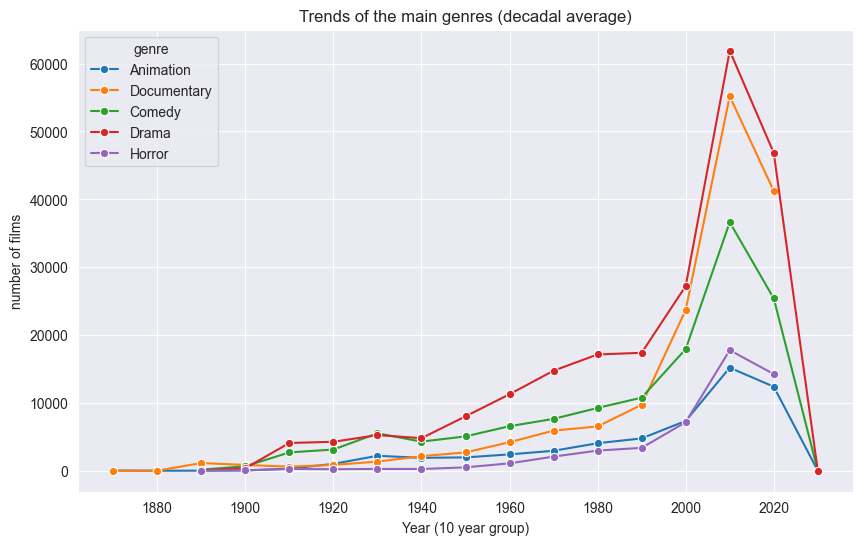

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown
import plotly.express as px

#Command for read csv.
movies = pd.read_csv("../data/cleaned/movie_clean.csv")
genres = pd.read_csv("../data/cleaned/genres_clean.csv")

#Merge genres and movie
df = pd.merge(genres, movies[['id', 'date']], on='id', how='left')

#Create columns by ten-year interval and group by five-year period and genre, I count films
df['year_group'] = (df['date'] // 10) * 10
genre_group_counts = df.groupby(['year_group', 'genre']).size().reset_index(name='count')

#Find the 5 genres with the most total films
top_genres = df['genre'].value_counts().head(5).index.tolist()
#Print as markdown
display(Markdown(f"**Top genres:** {', '.join(top_genres)}"))

#I create the lineplot chart by filtering on top genres and setting chart sizes
plt.figure(figsize=(10,6))
sns.lineplot(data=genre_group_counts[genre_group_counts['genre'].isin(top_genres)],
             x='year_group', y='count', hue='genre', marker='o')
plt.title('Trends of the main genres (decadal average)')
plt.xlabel('Year (10 year group)')
plt.ylabel('number of films')
plt.show()


## Description:
The lineplot graph "Trends of the main genres (decadal average)" illustrates the quantitative evolution of film production, measured as the number of films per ten-year average, for five main genres: Drama, Comedy, Documentary, Horror and Animation, from the decade 1880 to 2024. The overall analysis reveals a trend common to all genres: slow but steady growth from the end of the 19th century until the second half of the 20th century, followed by exponential growth starting in the 1990s.
### Specific Analysis of Genres
- Drama: Throughout the period analyzed, its line surpasses that of all other genres, indicating a consistently higher production volume. Its growth peaked at 60,000 in the 2010s.
- Documentary: Despite starting from very low numbers, this genre shows significant growth. In the 2010s it boomed, becoming the second most produced genre with around 55,000 films, almost reaching the Drama genre.
- Commedia: Per lungo tempo è stato il secondo genere più popolare, ma è stato superato dai documentari nel picco degli anni 2010. Segue comunque la tendenza generale di forte crescita.
- Horror e Animazione (Animation): Questi due generi hanno volumi di produzione inferiori rispetto agli altri, ma seguono esattamente lo stesso andamento, con una crescita costante e un picco molto marcato negli anni 2010.

### Are the most produced genres appreciated by the public?

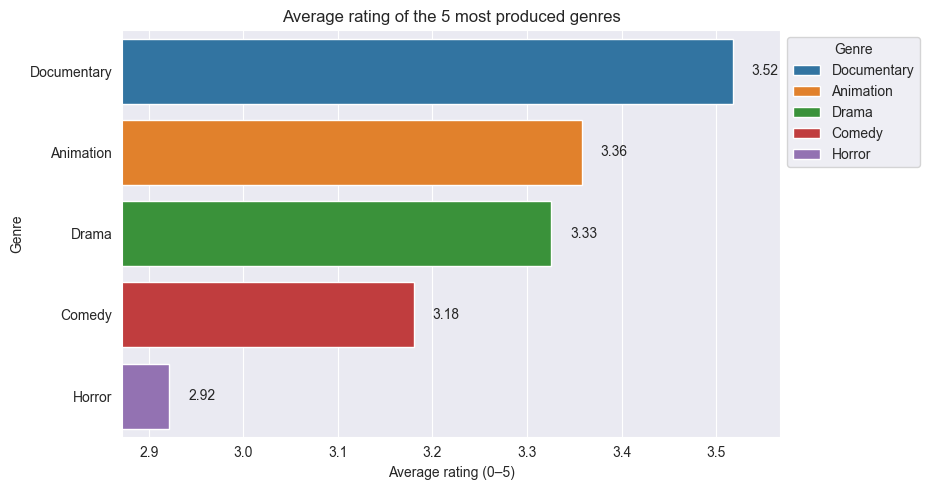

In [26]:
# Merge id-rating
df = pd.merge(genres, movies[['id', 'rating']], on='id', how='left')
# Calculation of the average rating for each genre
genre_ratings = df.groupby('genre')['rating'].mean().reset_index()

# I sort genres by decreasing rating
genre_ratings_sorted = genre_ratings.sort_values(by="rating", ascending=False)

# I filter only those that are in the top_genres
top5_ratings = genre_ratings_sorted[genre_ratings_sorted['genre'].isin(top_genres)].reset_index(drop=True)


# I create the horizontal bar chart for readability
plt.figure(figsize=(8,5))
sns.barplot(data=top5_ratings, x="rating", y="genre", hue="genre", palette="tab10", legend=True)

# Add values above bars
for index, row in top5_ratings.sort_values(by="rating", ascending=True).iterrows():
    plt.text(row["rating"] + 0.02, index, f"{row['rating']:.2f}", va='center')

# Title and aces
plt.title("Average rating of the 5 most produced genres")
plt.xlabel("Average rating (0–5)")
plt.ylabel("Genre")
plt.tight_layout()
# I narrow the x-axis to bring out the differences
min_rating = top5_ratings['rating'].min() - 0.05
max_rating = top5_ratings['rating'].max() + 0.05
plt.xlim(min_rating, max_rating)
plt.tight_layout()

#I move the legend to the top left
plt.legend(title="Genre", loc='upper left', bbox_to_anchor=(1,1))
plt.show()

## Description:
The graph represents the average rating of the top 5 most produced genres. This is a horizontal bar chart, where the y-axis indicates the genres, the x-axis the average rating on a scale of 0 to 5. The genre with the highest average rating is Documentary (3.52), followed by Animation (3.36), Drama (3.33), Comedy (3.18) and Horror (2.92). The differences between the genres are rather limited, apart from Horrors. Each bar shows the value of the average rating alongside, making visible which genre is most appreciated by the public. In summary, the graph illustrates clearly and immediately that, among the most common genres, documentaries are the most appreciated in terms of rating, while horror films receive the lowest scores on average.

### Are the 5 genres most appreciated by the public the most popular in that period?
##### Before you answer, you need a graph that shows the genre that is most popular with the public.

**Top genres:** Documentary, Music, History, War, Animation

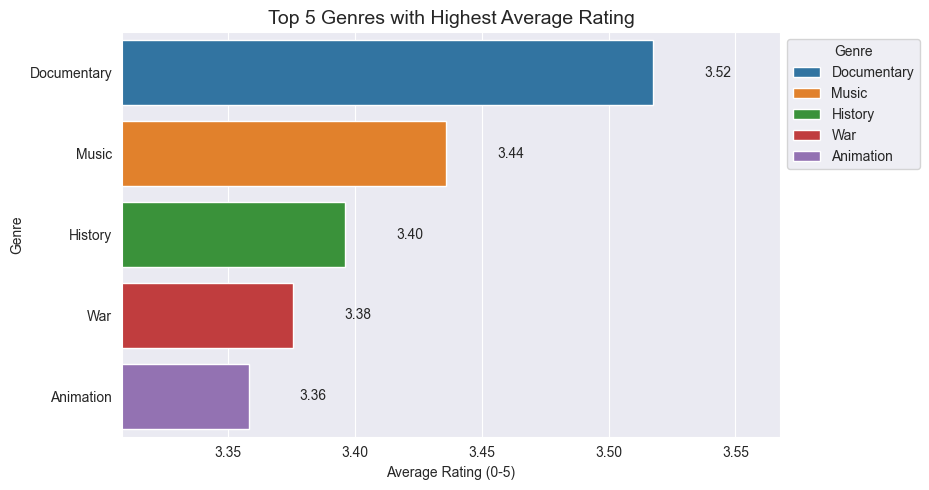

In [27]:
# Get top 5 genres and sort from highest to lowest
top5_genres = genre_ratings.sort_values(by='rating', ascending=False).head(5).reset_index(drop=True)

# Top 5 genres of markdown printing
display(Markdown(f"**Top genres:** {', '.join(top5_genres['genre'])}"))

# I create the horizontal bar chart for readability
plt.figure(figsize=(8,5))
sns.barplot(
    data=top5_genres,
    y='genre', x='rating',
    hue='genre', palette='tab10', legend=True
)

# Add values above bars
for index, row in top5_genres.iterrows():
    plt.text(row['rating'] + 0.02, index, f"{row['rating']:.2f}", va='center')

# Title and aces
plt.title("Top 5 Genres with Highest Average Rating", fontsize=14)
plt.xlabel("Average Rating (0-5)")
plt.ylabel("Genre")

# I narrow the x-axis to bring out the differences
min_rating = top5_genres['rating'].min() - 0.05
max_rating = top5_genres['rating'].max() + 0.05
plt.xlim(min_rating, max_rating)
plt.tight_layout()
#I move the legend to the top left
plt.legend(title="Genre", loc='upper left', bbox_to_anchor=(1,1))
plt.show()

## Description:
The graph represents the Top 5 genres with the highest average rating assigned by the public. It is a horizontal barplot, where the y-axis indicates genres and the x-axis the average rating on a scale of 0 to 5.
The genre with the highest average rating is Documentary (3.52), followed by Music (3.44), History (3.40), War (3.38) and Animation (3.36). The differences between the genres are quite limited.
Each bar shows the value of the average rating alongside, making it visible which genre is most appreciated by the public.
the public tends to reward mainly documentaries and music, while genres such as animation, despite being among the top 5, have a slightly lower rating. The differences are minimal but significant for understanding general preferences.

### Graphs compared: the genres chosen by the public vs. the rating of the most produced genres over time.

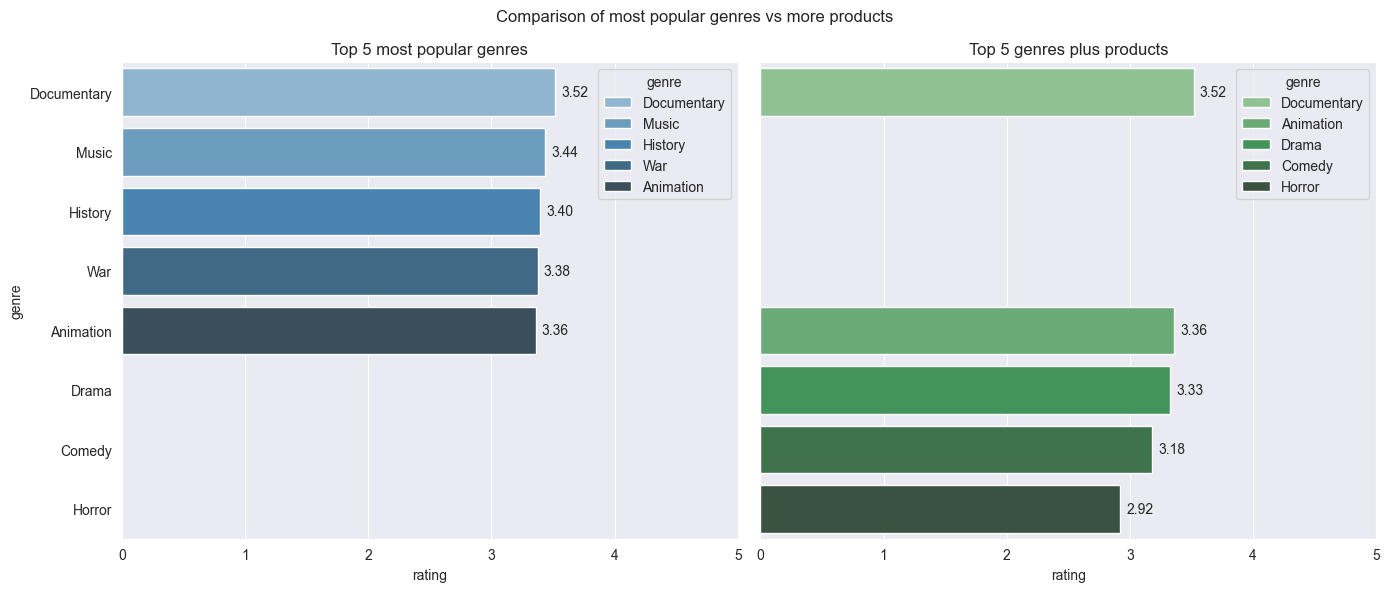

In [28]:
# Create a figure with 1 riga e 2 colonne di subplot, condividendo l'asse y
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# First chart: top 5 most popular genres
sns.barplot(data=top5_genres, hue='genre', x="rating", y="genre", ax=axes[0], palette="Blues_d", legend=True)
axes[0].set_title("Top 5 most popular genres")
axes[0].set_xlim(0,5)

# I print the rating next to the bar
for i, v in enumerate(top5_genres["rating"]):
    axes[0].text(v + 0.05, i, f"{v:.2f}", va='center')

# First chart: Top 5 genres plus products
sns.barplot(data=top5_ratings, hue='genre', x="rating", y="genre", ax=axes[1], palette="Greens_d", legend=True)
axes[1].set_title("Top 5 genres plus products")
axes[1].set_xlim(0,5)

# I print the rating next to the unorganized bar
for p in axes[1].patches:
    if p.get_width() > 0:
        axes[1].text(
            p.get_width() + 0.05,
            p.get_y() + p.get_height() / 2,
            f"{p.get_width():.2f}",
            va='center'
    )

# General title and compact layout
plt.suptitle("Comparison of most popular genres vs more products")
plt.tight_layout()
plt.show()

## Description:
The graph compares the average rating of films in the five most produced genres and in the 5 most popular genres.
Green bars represent the most produced genres, showing how their popularity in terms of quantity does not always correspond to high public approval.
The blue bars, on the other hand, highlight the genres with the highest average scores, i.e. those that obtained the best overall ratings.
- Overproduction of unappreciated genres: Comparing the first graph with this one there is a clear overproduction of Drama and Comedy films compared to their actual audience approval. This suggests a misalignment between what the industry produces and what the public really wants.

- Quality of Documentaries: The Documentary genre is an exception. Not only has it experienced exponential growth in production, but it is also the most popular genre. This indicates that the industry is responding to high-quality demand for this specific genre.

In summary, the data shows that the film industry tends to produce in large quantities the genres that have historically been successful, such as Drama and Comedy, but not necessarily those that are the most popular today. Documentaries seem to be the only genre in which production and audience approval are aligned.


### In which countries are the top 5 most produced genres produced?


In [29]:
# I take the CSV of the countries
country = pd.read_csv("../data/cleaned/countries_clean.csv")

# 5 gernres most produced
top5 = top5_ratings['genre'].tolist()
df_top5 = genres[genres['genre'].isin(top5)]
df_top5 = pd.merge(df_top5, country, on='id')


# Group by country and genres and I count the products
country_genre = df_top5.groupby(['country','genre'])['id'].count().reset_index()
country_genre.rename(columns={'id':'count'}, inplace=True)

# Interactive map
fig = px.choropleth(
    country_genre,
    locations='country',
    locationmode='ISO-3',
    color='count',
    hover_name='country',
    hover_data=['genre','count'],
    animation_frame='genre',
    color_continuous_scale='Viridis'
)

fig.update_layout(title="Distribution of the 5 genres plus products by country")
fig.show()


## Description:
This graph is an interactive geographic map (coropleta) showing the distribution of the five most produced genres in the dataset. The countries represented are all those in which they were produced and the number for each country is indicated by the color on the map.

### Specific Analysis of Genres
By looking at the map, you can move between different genres and see which countries were produced the most:

- Comedy: The United States leads with 38,213 productions, followed by France with 9,500.

- Documentary: the United States remains in first place with 32,430, followed by the United Kingdom with 12,422 and France with 11,929.

- Drama: the United States predominates with 46,837 productions; France and Germany follow with around 14,500, while the United Kingdom and India stand at around 11,000.

- Animation: the United States leads with 15,750 productions, followed by Japan with 7,908.

- Horror: The United States still ranks first with 18,188 productions, followed by Japan with 5,484.

In all genres, the United States always occupies the first position, confirming its dominant role in content production.

## In which countries are the most popular top 5 genres produced?

In [30]:
# I merge the two DataFrames
df = pd.merge(genres, country, on="id")

# I take only the 5 most popular genres (already calculated in top5_genres)
top5_popular = top5_genres['genre'].tolist()
df_top5_popular = df[df['genre'].isin(top5_popular)]

# Group by country and gender, counting products
country_genre_popular = (
    df_top5_popular
    .groupby(['country', 'genre'])['id']
    .count()
    .reset_index(name='count')
)

# interactive map
fig = px.choropleth(
    country_genre_popular,
    locations='country',
    locationmode='ISO-3',
    color='count',
    hover_name='country',
    hover_data=['genre', 'count'],
    animation_frame='genre',
    color_continuous_scale='Viridis'
)

fig.update_layout(title="Distribution of the 5 genres most appreciated by the public by country")
fig.show()

## Description:
This graph is an interactive geographic map (coropleta) showing the distribution of the five most valued genres in the dataset. The countries represented are all those in which they were produced and the number for each country is indicated by the color on the map.

### Specific Analysis of Genres
By looking at the map, you can move between different genres and see which countries were produced the most:

- Documentary: the United States remains in first place with 32,430, followed by the United Kingdom with 12,422 and France with 11,929.

- Music: USA = 10.025, UK (GBR) = 3.045 The musical genre is positioned as the second most appreciated by the public, immediately after documentaries. Despite the high approval rating, the graph shows that its production is limited, with only two countries producing significant quantities of it.

- Animation: The United States leads with 15,750 productions, followed by Japan with 7,908. The data shows that this genre is among the most produced globally, with much higher numbers than Music and History, despite having a lower approval rating.

- History: USA = 3,243, France = 1,842 The production of historical films is mainly concentrated in two countries, with much lower numbers than the most popular genres.

- War: USA = 2,646, UK (GBR) = 958 This genus is the least produced among those analyzed. Only the United States exceeds 1,000 productions, while other countries do not reach this threshold.

USA: 2,646
United Kingdom (GBR): 958

### Conclusions:
The combined analysis of the data highlights a clear misalignment between film production and audience approval. While genres with high approval ratings, such as Musical, have limited production, genres such as Animation are produced in massive quantities, despite not being the most popular. Data on the Guerra genre indicate very low production.